In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Check library versions
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Seaborn:", sns.__version__)
print("All libraries loaded successfully ")

Pandas: 2.2.3
NumPy: 2.2.4
Seaborn: 0.13.2
All libraries loaded successfully 


In [5]:
path = 'E:/Projects/Ecommerce-Analysis/data/'

orders = pd.read_csv(path + 'olist_orders_dataset.csv')
customers = pd.read_csv(path + 'olist_customers_dataset.csv')
order_items = pd.read_csv(path + 'olist_order_items_dataset.csv')
products = pd.read_csv(path + 'olist_products_dataset.csv')
sellers = pd.read_csv(path + 'olist_sellers_dataset.csv')
payments = pd.read_csv(path + 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(path + 'olist_order_reviews_dataset.csv')
category_translation = pd.read_csv(path + 'product_category_name_translation.csv')

print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Payments:", payments.shape)
print("Reviews:", reviews.shape)
print("\nAll datasets loaded successfully")

Orders: (99441, 8)
Customers: (99441, 5)
Order Items: (112650, 7)
Products: (32951, 9)
Payments: (103886, 5)
Reviews: (99224, 7)

All datasets loaded successfully


In [6]:
print("=== MISSING VALUES ===\n")
datasets = {
    'Orders': orders,
    'Customers': customers,
    'Order Items': order_items,
    'Products': products,
    'Payments': payments,
    'Reviews': reviews
}

for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values")

=== MISSING VALUES ===

Orders: 4908 missing values
Customers: 0 missing values
Order Items: 0 missing values
Products: 2448 missing values
Payments: 0 missing values
Reviews: 145903 missing values


In [7]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Keep only delivered orders for analysis
orders_clean = orders[orders['order_status'] == 'delivered'].copy()

# Extract useful time features
orders_clean['order_year'] = orders_clean['order_purchase_timestamp'].dt.year
orders_clean['order_month'] = orders_clean['order_purchase_timestamp'].dt.month
orders_clean['order_month_name'] = orders_clean['order_purchase_timestamp'].dt.month_name()
orders_clean['order_day'] = orders_clean['order_purchase_timestamp'].dt.day_name()

# Calculate delivery time in days
orders_clean['delivery_days'] = (
    orders_clean['order_delivered_customer_date'] -
    orders_clean['order_purchase_timestamp']
).dt.days

print("Orders cleaned ")
print(f"Total delivered orders: {len(orders_clean)}")
print(f"\nDate range: {orders_clean['order_purchase_timestamp'].min().date()} "
      f"to {orders_clean['order_purchase_timestamp'].max().date()}")

Orders cleaned 
Total delivered orders: 96478

Date range: 2016-09-15 to 2018-08-29


In [8]:
# Merge English category names
products_clean = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)

# Fill missing category names
products_clean['product_category_name_english'].fillna('unknown', inplace=True)

# Drop columns not needed
products_clean = products_clean[[
    'product_id',
    'product_category_name_english',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]]

print("Products cleaned ")
print(f"Total products: {len(products_clean)}")
print(f"Unique categories: {products_clean['product_category_name_english'].nunique()}")

Products cleaned 
Total products: 32951
Unique categories: 72


C:\Users\DELL\AppData\Local\Temp\ipykernel_11156\601215036.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_clean['product_category_name_english'].fillna('unknown', inplace=True)


In [9]:
reviews_clean = reviews[[
    'order_id',
    'review_score',
    'review_comment_message'
]].copy()

# Fill missing comments
reviews_clean['review_comment_message'].fillna('No comment', inplace=True)

print("Reviews cleaned ")
print(f"Average review score: {reviews_clean['review_score'].mean():.2f} / 5")
print(f"Review score distribution:\n{reviews_clean['review_score'].value_counts().sort_index()}")

Reviews cleaned 
Average review score: 4.09 / 5
Review score distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_11156\1232643012.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  reviews_clean['review_comment_message'].fillna('No comment', inplace=True)


In [10]:
# Step 1: orders + customers
master = orders_clean.merge(customers, on='customer_id', how='left')

# Step 2: + order items
master = master.merge(order_items, on='order_id', how='left')

# Step 3: + products (with english category names)
master = master.merge(products_clean, on='product_id', how='left')

# Step 4: + payments
payment_summary = payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_type=('payment_type', 'first')
).reset_index()
master = master.merge(payment_summary, on='order_id', how='left')

# Step 5: + reviews
master = master.merge(reviews_clean, on='order_id', how='left')

print("Master dataframe created ")
print(f"Shape: {master.shape}")
print(f"\nColumns: {list(master.columns)}")

Master dataframe created 
Shape: (110840, 32)

Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_year', 'order_month', 'order_month_name', 'order_day', 'delivery_days', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name_english', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'total_payment', 'payment_type', 'review_score', 'review_comment_message']


In [12]:
print("=== MASTER DATAFRAME SUMMARY ===\n")
print(f"Total rows: {master.shape[0]:,}")
print(f"Total columns: {master.shape[1]}")
print(f"\nDate range: {master['order_purchase_timestamp'].min().date()} "
      f"to {master['order_purchase_timestamp'].max().date()}")
print(f"\nTotal revenue: R$ {master['total_payment'].sum():,.2f}")
print(f"Unique customers: {master['customer_id'].nunique():,}")
print(f"Unique products: {master['product_id'].nunique():,}")
print(f"Unique categories: {master['product_category_name_english'].nunique()}")
print(f"Average delivery time: {master['delivery_days'].mean():.1f} days")
print(f"Average review score: {master['review_score'].mean():.2f} / 5")

# Save cleaned master file for Power BI later
master.to_csv('E:/Projects/Ecommerce-Analysis/data/master_clean.csv', index=False)
print("\nMaster file saved for Power BI ")

=== MASTER DATAFRAME SUMMARY ===

Total rows: 110,840
Total columns: 32

Date range: 2016-09-15 to 2018-08-29

Total revenue: R$ 19,881,945.07
Unique customers: 96,478
Unique products: 32,216
Unique categories: 72
Average delivery time: 12.0 days
Average review score: 4.08 / 5

Master file saved for Power BI 


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create images folder
os.makedirs('E:/Projects/Ecommerce-Analysis/images/', exist_ok=True)

# Set global style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")
sns.set_palette("husl")

print("Styling ready ")

Styling ready 


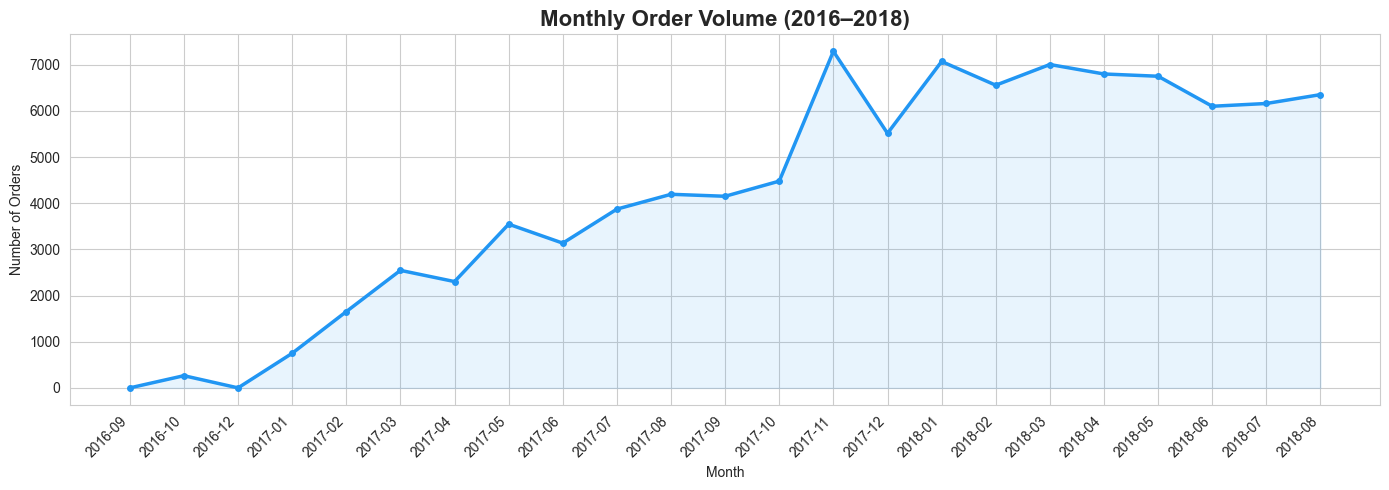

Chart 1 saved


In [14]:
monthly_orders = master.groupby(
    ['order_year', 'order_month']
)['order_id'].nunique().reset_index()
monthly_orders['period'] = (
    monthly_orders['order_year'].astype(str) + '-' +
    monthly_orders['order_month'].astype(str).str.zfill(2)
)

plt.figure(figsize=(14, 5))
plt.plot(monthly_orders['period'], monthly_orders['order_id'],
         color='#2196F3', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(monthly_orders['period'],
                 monthly_orders['order_id'], alpha=0.1, color='#2196F3')
plt.title('Monthly Order Volume (2016–2018)', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('E:/Projects/Ecommerce-Analysis/images/1_monthly_orders.png', dpi=150)
plt.show()
print("Chart 1 saved")


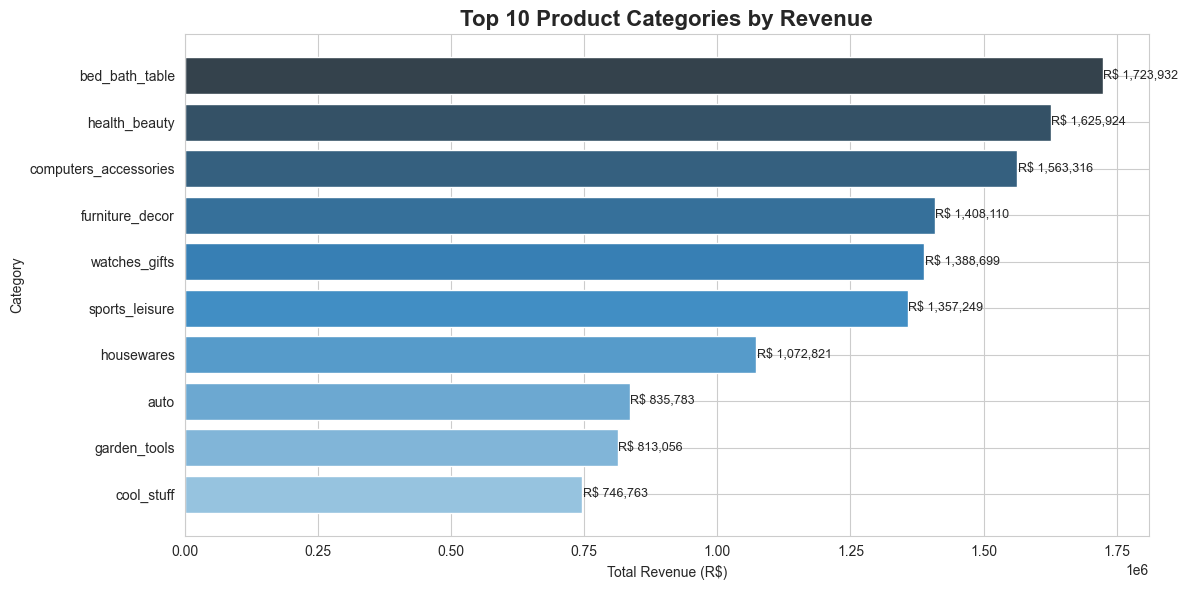

 Chart 2 saved


In [15]:
category_revenue = master.groupby(
    'product_category_name_english'
)['total_payment'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(category_revenue.index[::-1],
                category_revenue.values[::-1],
                color=sns.color_palette("Blues_d", 10))
plt.title('Top 10 Product Categories by Revenue', fontsize=16, fontweight='bold')
plt.xlabel('Total Revenue (R$)')
plt.ylabel('Category')
for i, (val, bar) in enumerate(zip(category_revenue.values[::-1], bars)):
    plt.text(val + 1000, bar.get_y() + bar.get_height()/2,
             f'R$ {val:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('E:/Projects/Ecommerce-Analysis/images/2_top_categories.png', dpi=150)
plt.show()
print(" Chart 2 saved")

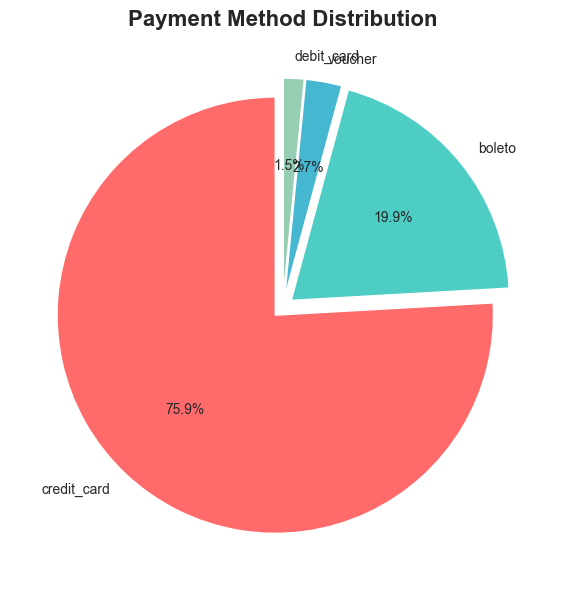

Chart 3 saved


In [16]:
payment_counts = master.groupby(
    'payment_type'
)['order_id'].nunique().sort_values(ascending=False)

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
plt.figure(figsize=(8, 6))
plt.pie(payment_counts.values,
        labels=payment_counts.index,
        autopct='%1.1f%%',
        colors=colors,
        startangle=90,
        explode=[0.05] * len(payment_counts))
plt.title('Payment Method Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('E:/Projects/Ecommerce-Analysis/images/3_payment_methods.png', dpi=150)
plt.show()
print("Chart 3 saved")

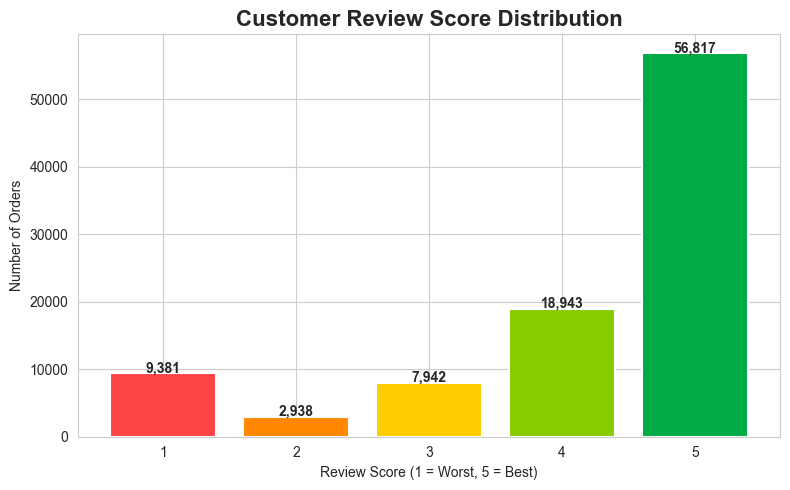

Chart 4 saved


In [17]:
review_counts = master.groupby(
    'review_score'
)['order_id'].nunique()

colors = ['#FF4444', '#FF8800', '#FFCC00', '#88CC00', '#00AA44']
plt.figure(figsize=(8, 5))
bars = plt.bar(review_counts.index, review_counts.values,
               color=colors, edgecolor='white', linewidth=1.5)
plt.title('Customer Review Score Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Review Score (1 = Worst, 5 = Best)')
plt.ylabel('Number of Orders')
for bar, val in zip(bars, review_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f'{val:,}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('E:/Projects/Ecommerce-Analysis/images/4_review_scores.png', dpi=150)
plt.show()
print("Chart 4 saved")

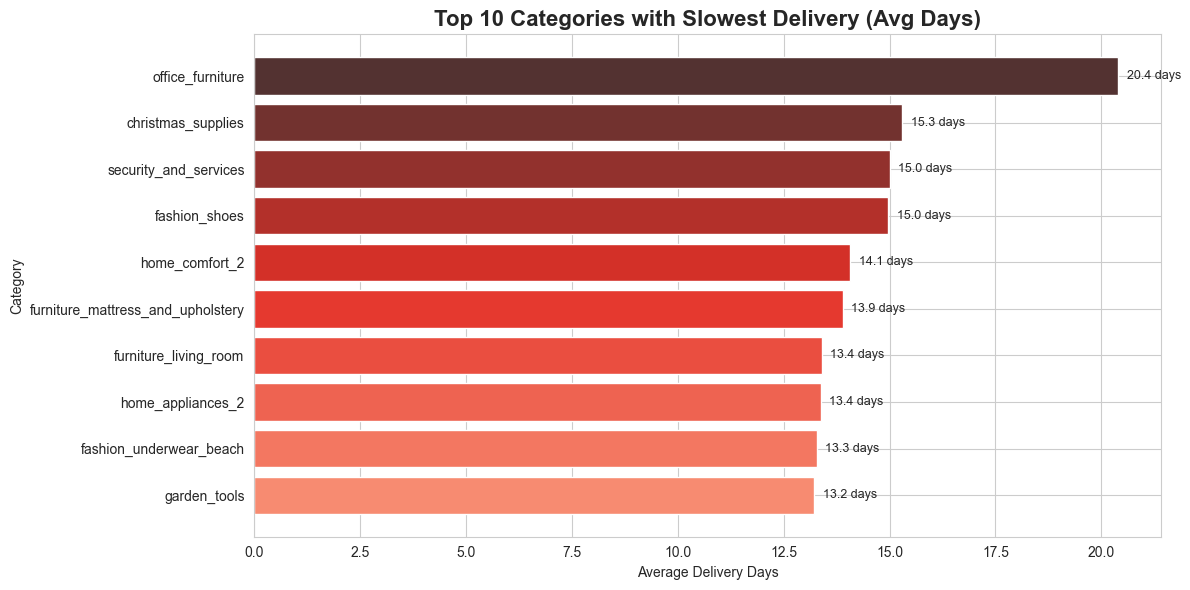

Chart 5 saved


In [18]:
delivery_by_cat = master.groupby(
    'product_category_name_english'
)['delivery_days'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(delivery_by_cat.index[::-1],
                delivery_by_cat.values[::-1],
                color=sns.color_palette("Reds_d", 10))
plt.title('Top 10 Categories with Slowest Delivery (Avg Days)',
          fontsize=16, fontweight='bold')
plt.xlabel('Average Delivery Days')
plt.ylabel('Category')
for i, (val, bar) in enumerate(zip(delivery_by_cat.values[::-1], bars)):
    plt.text(val + 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f} days', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('E:/Projects/Ecommerce-Analysis/images/5_delivery_time.png', dpi=150)
plt.show()
print("Chart 5 saved")

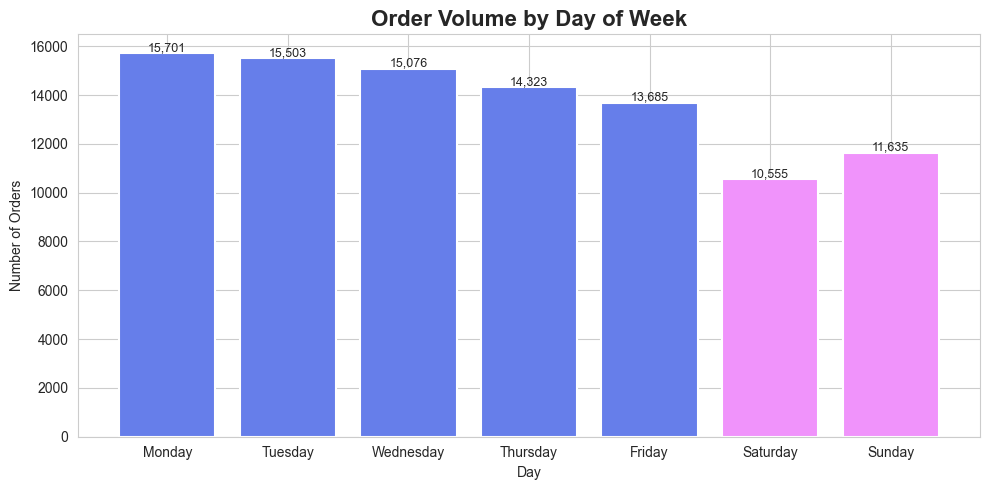

Chart 6 saved


In [19]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_counts = master.groupby('order_day')['order_id'].nunique().reindex(day_order)

plt.figure(figsize=(10, 5))
bars = plt.bar(day_counts.index, day_counts.values,
               color=['#667eea' if d not in ['Saturday','Sunday']
                      else '#f093fb' for d in day_order],
               edgecolor='white', linewidth=1.5)
plt.title('Order Volume by Day of Week', fontsize=16, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
for bar, val in zip(bars, day_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('E:/Projects/Ecommerce-Analysis/images/6_orders_by_day.png', dpi=150)
plt.show()
print("Chart 6 saved")

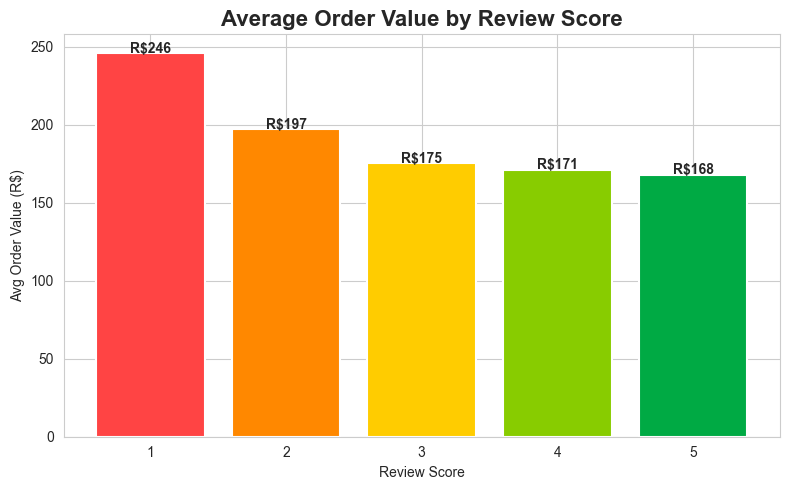

 Chart 7 saved


In [20]:
avg_value_by_review = master.groupby(
    'review_score'
)['total_payment'].mean()

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_value_by_review.index,
               avg_value_by_review.values,
               color=['#FF4444','#FF8800','#FFCC00','#88CC00','#00AA44'],
               edgecolor='white', linewidth=1.5)
plt.title('Average Order Value by Review Score',
          fontsize=16, fontweight='bold')
plt.xlabel('Review Score')
plt.ylabel('Avg Order Value (R$)')
for bar, val in zip(bars, avg_value_by_review.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'R${val:.0f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('E:/Projects/Ecommerce-Analysis/images/7_revenue_vs_review.png', dpi=150)
plt.show()
print(" Chart 7 saved")

In [22]:
print("=" * 55)
print("       KEY BUSINESS INSIGHTS")
print("=" * 55)

# Insight 1
top_cat = category_revenue.index[0]
top_rev = category_revenue.values[0]
print(f"\n Insight 1 — Top Revenue Category")
print(f"   '{top_cat}' generates R${top_rev:,.0f} in revenue")
print(f"   → Focus marketing budget on this category")

# Insight 2
credit_pct = (payment_counts.get('credit_card', 0) /
              payment_counts.sum() * 100)
print(f"\n Insight 2 — Payment Preference")
print(f"   {credit_pct:.1f}% of customers pay via credit card")
print(f"   → Offer EMI schemes to increase avg order value")

# Insight 3
five_star_pct = (review_counts.get(5, 0) /
                 review_counts.sum() * 100)
print(f"\n Insight 3 — Customer Satisfaction")
print(f"   {five_star_pct:.1f}% of orders receive 5-star reviews")
print(f"   → Identify what 5-star orders have in common")

# Insight 4
avg_delivery = master['delivery_days'].mean()
print(f"\n Insight 4 — Delivery Performance")
print(f"   Average delivery time is {avg_delivery:.1f} days")
print(f"   → Reducing to under 7 days could boost ratings")

# Insight 5
best_day = day_counts.idxmax()
worst_day = day_counts.idxmin()
print(f"\n Insight 5 — Peak Order Days")
print(f"   Most orders placed on {best_day}")
print(f"   Least orders on {worst_day}")
print(f"   → Run flash sales on {worst_day} to boost volume")

print("\n" + "=" * 55)
print("Analysis Complete ")

       KEY BUSINESS INSIGHTS

 Insight 1 — Top Revenue Category
   'bed_bath_table' generates R$1,723,932 in revenue
   → Focus marketing budget on this category

 Insight 2 — Payment Preference
   75.9% of customers pay via credit card
   → Offer EMI schemes to increase avg order value

 Insight 3 — Customer Satisfaction
   59.2% of orders receive 5-star reviews
   → Identify what 5-star orders have in common

 Insight 4 — Delivery Performance
   Average delivery time is 12.0 days
   → Reducing to under 7 days could boost ratings

 Insight 5 — Peak Order Days
   Most orders placed on Monday
   Least orders on Saturday
   → Run flash sales on Saturday to boost volume

Analysis Complete 
